# LSTM Autoencoder

Sequence-aware detector. Trained only on normal 20-reading windows to learn
to reconstruct normal patterns well. Anomalous sequences reconstruct poorly
— that reconstruction error becomes our anomaly score.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import precision_score, recall_score, f1_score

ML_DIR = Path("../ml_models")

In [2]:
X_train_seq = np.load(ML_DIR / "X_train_seq.npy")
X_test_seq  = np.load(ML_DIR / "X_test_seq.npy")
y_train_seq = np.load(ML_DIR / "y_train_seq.npy")
y_test_seq  = np.load(ML_DIR / "y_test_seq.npy")

print("Train sequences:", X_train_seq.shape)   # (n_windows, 20, 28)
print("Test sequences: ", X_test_seq.shape)

Train sequences: (12756, 20, 28)
Test sequences:  (3175, 20, 28)


## Same design decision as Isolation Forest

Train only on normal sequences. The photocopier should only ever practice
on normal documents — mixing in anomalous sequences during training would
teach it to reproduce anomalies well too, which defeats the purpose.

In [3]:
X_train_normal_seq = X_train_seq[y_train_seq == 0]
print(f"Training sequences: {len(X_train_seq)} total → {len(X_train_normal_seq)} normal-only")

Training sequences: 12756 total → 10246 normal-only


## Building the autoencoder

Encoder: an LSTM reads all 20 timesteps and compresses the whole sequence
down into ONE small vector — the "gist" of what happened.

RepeatVector: copies that single gist vector 20 times, so the decoder has
something to work with for each of the 20 output timesteps.

Decoder: a second LSTM expands that gist back out into a full 20-timestep
sequence again — its attempt at reconstructing the original.

TimeDistributed(Dense): at every one of the 20 timesteps, maps the
decoder's output back into 28 numbers — one reconstructed reading.

In [4]:
SEQ_LEN = X_train_seq.shape[1]      # 20
N_FEATURES = X_train_seq.shape[2]   # 28

model = keras.Sequential([
    keras.Input(shape=(SEQ_LEN, N_FEATURES)),
    layers.LSTM(64, activation="tanh", return_sequences=False, name="encoder"),
    layers.RepeatVector(SEQ_LEN),
    layers.LSTM(64, activation="tanh", return_sequences=True, name="decoder"),
    layers.TimeDistributed(layers.Dense(N_FEATURES), name="reconstruction"),
])

model.compile(optimizer="adam", loss="mse")
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder (LSTM)                  │ (None, 64)             │        23,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (LSTM)                  │ (None, 20, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstruction                  │ (None, 20, 28)         │         1,820 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,652 (229.11 KB)

 Trainable params: 58,652 (229.11 KB)

 Non-trainable params: 0 (0.00 B)

## Training — notice the input IS the target

Normally in ML you train on (input, correct_answer) pairs. Here, the
"correct answer" for reconstructing a sequence is just... the same
sequence. That's the entire trick behind an autoencoder — it's graded on
how well it can reproduce its own input.

EarlyStopping watches the validation loss and stops training automatically
once it stops improving, so we don't waste time overfitting.

In [5]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=3, restore_best_weights=True
)

history = model.fit(
    X_train_normal_seq, X_train_normal_seq,   # input == target
    epochs=30,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1,
)

Epoch 1/30
145/145 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.8266 - val_loss: 0.4775
Epoch 2/30
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.7877 - val_loss: 0.4701
Epoch 3/30
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.7794 - val_loss: 0.4668
Epoch 4/30
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.7742 - val_loss: 0.4654
Epoch 5/30
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.7677 - val_loss: 0.4611
Epoch 6/30
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.7623 - val_loss: 0.4601
Epoch 7/30
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.7579 - val_loss: 0.4594
Epoch 8/30
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.7554 - val_loss: 0.4585
Epoch 9/30
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.7473 - val_loss: 0.4544
Epoch 10/30
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.7462 - val_loss: 0.4552
Epoch 11/30
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.7437 - val_loss: 0.4524
Epoch 12/30
145/145 ━━━━━━━━━━━━━━━━━━━━ 

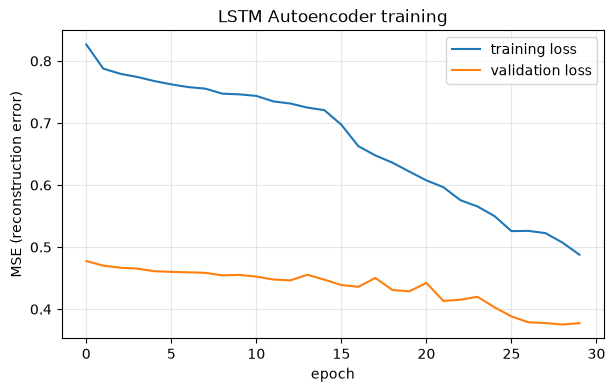

In [6]:
plt.figure(figsize=(7, 4))
plt.plot(history.history["loss"], label="training loss")
plt.plot(history.history["val_loss"], label="validation loss")
plt.xlabel("epoch")
plt.ylabel("MSE (reconstruction error)")
plt.title("LSTM Autoencoder training")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Computing reconstruction error for every sequence

For each sequence, we ask the model to reconstruct it, then measure how
different the reconstruction is from the original — averaged across all
20 timesteps and 28 features into one single error number per sequence.

In [7]:
def reconstruction_error(model, X):
    X_pred = model.predict(X, verbose=0)
    return np.mean(np.square(X - X_pred), axis=(1, 2))

train_errors = reconstruction_error(model, X_train_seq)
test_errors  = reconstruction_error(model, X_test_seq)

print("Train error range:", train_errors.min(), "to", train_errors.max())

Train error range: 0.059409965 to 32.210014


In [13]:
# Sweep by PERCENTILE of the error distribution, not raw value spacing.
# This concentrates candidate thresholds where the data is actually dense,
# instead of wasting most of them on a mostly-empty long tail caused by a
# few extreme-error outlier readings.
percentiles = np.linspace(50, 99.5, 60)
thresholds = np.unique(np.percentile(train_errors, percentiles))

results = []
for t in thresholds:
    y_pred = lstm_predict(train_errors, t)
    results.append({
        "threshold": t,
        "precision": precision_score(y_train_seq, y_pred, zero_division=0),
        "recall":    recall_score(y_train_seq, y_pred, zero_division=0),
        "f1":        f1_score(y_train_seq, y_pred, zero_division=0),
    })

results_df = pd.DataFrame(results)
results_df

,threshold,precision,recall,f1
0,0.198043,0.288962,0.734263,0.414716
1,0.200871,0.292138,0.729880,0.417265
2,0.204224,0.293965,0.721912,0.417800
3,0.208126,0.296847,0.716335,0.419750
4,0.212413,0.298319,0.707171,0.419622
5,0.217305,0.300873,0.700398,0.420927
6,0.222079,0.302824,0.692032,0.421295
7,0.227550,0.304317,0.682470,0.420936
8,0.233577,0.307316,0.676096,0.422560
9,0.238925,0.309141,0.666932,0.422461


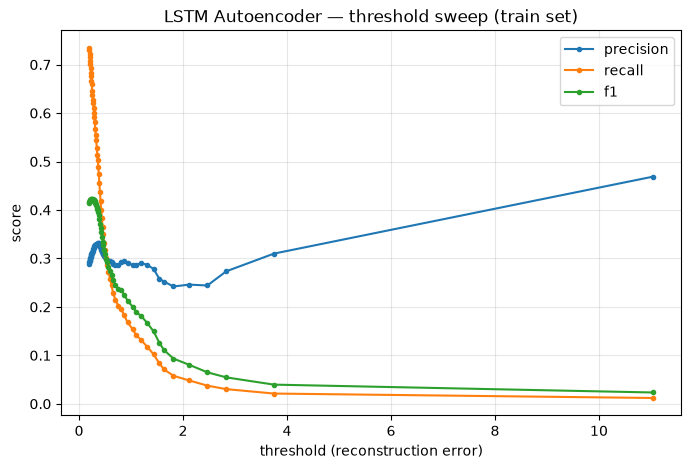

Best threshold: 0.244587  (F1=0.423)


In [14]:
plt.figure(figsize=(8, 5))
plt.plot(results_df["threshold"], results_df["precision"], label="precision", marker="o", markersize=3)
plt.plot(results_df["threshold"], results_df["recall"],    label="recall",    marker="o", markersize=3)
plt.plot(results_df["threshold"], results_df["f1"],        label="f1",       marker="o", markersize=3)
plt.xlabel("threshold (reconstruction error)")
plt.ylabel("score")
plt.title("LSTM Autoencoder — threshold sweep (train set)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

best_row = results_df.loc[results_df["f1"].idxmax()]
print(f"Best threshold: {best_row['threshold']:.6f}  (F1={best_row['f1']:.3f})")

In [15]:
best_threshold = float(best_row["threshold"])
y_pred_test = lstm_predict(test_errors, best_threshold)

print(f"Test set results (threshold={best_threshold:.6f}):")
print(f"  Precision: {precision_score(y_test_seq, y_pred_test):.3f}")
print(f"  Recall:    {recall_score(y_test_seq, y_pred_test):.3f}")
print(f"  F1 score:  {f1_score(y_test_seq, y_pred_test):.3f}")

Test set results (threshold=0.244587):
  Precision: 0.394
  Recall:    0.641
  F1 score:  0.488


In [16]:
model.save(ML_DIR / "lstm_autoencoder.keras")

config = {
    "detector": "lstm_autoencoder",
    "threshold": best_threshold,
    "seq_len": SEQ_LEN,
    "n_features": N_FEATURES,
    "trained_on": "X_train_seq normal-only sequences",
}
with open(ML_DIR / "lstm_config.json", "w") as f:
    json.dump(config, f, indent=2)

print("Saved lstm_autoencoder.keras and lstm_config.json")
print(config)

Saved lstm_autoencoder.keras and lstm_config.json
{'detector': 'lstm_autoencoder', 'threshold': 0.24458732411770495, 'seq_len': 20, 'n_features': 28, 'trained_on': 'X_train_seq normal-only sequences'}
